Número de amostras (Nt)
100000


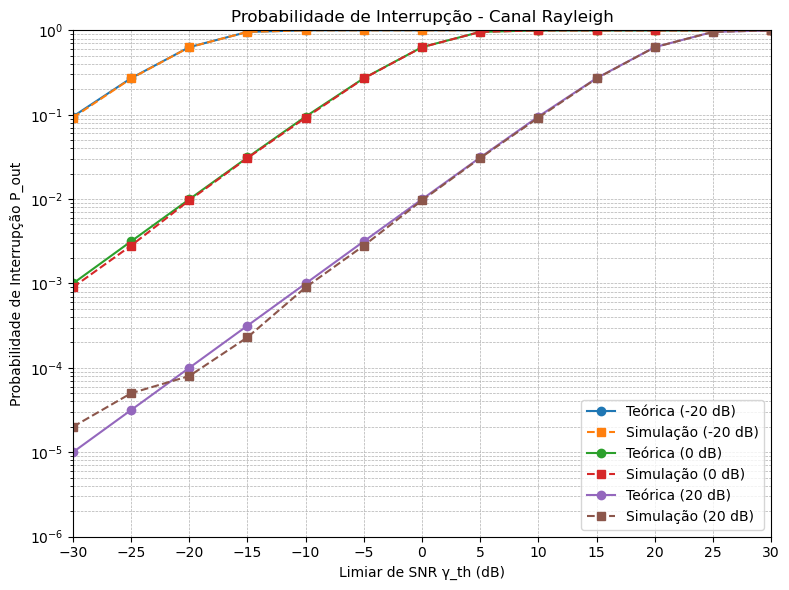

Número de amostras (Nt)
100000


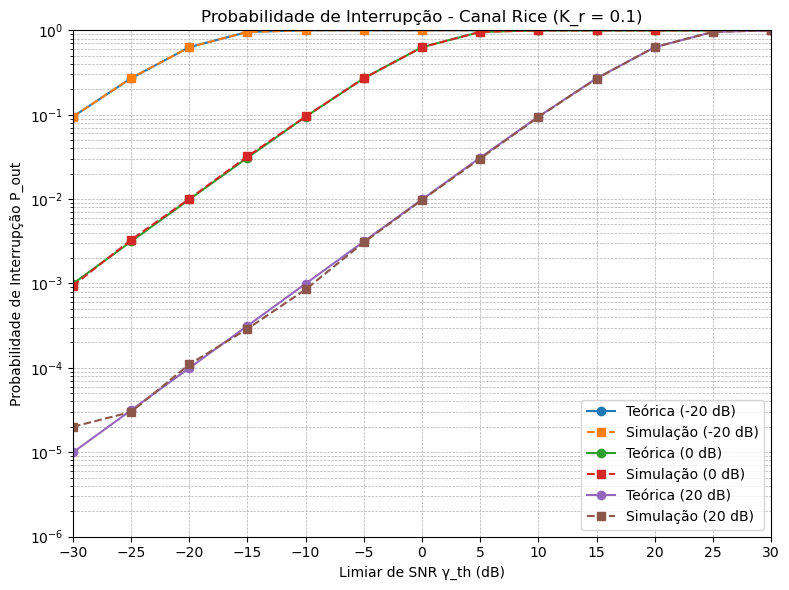

C:\Users\takeshi\AppData\Local\Temp\ipykernel_23476\1034097603.py:128: RuntimeWarning: invalid value encountered in scalar multiply
  return x * np.exp(-(x**2 + a**2)/2) * i0(a*x)
C:\Users\takeshi\AppData\Local\Temp\ipykernel_23476\1034097603.py:131: IntegrationWarning: The maximum number of subdivisions (50) has been achieved.
  If increasing the limit yields no improvement it is advised to analyze 
  the integrand in order to determine the difficulties.  If the position of a 
  local difficulty can be determined (singularity, discontinuity) one will 
  probably gain from splitting up the interval and calling the integrator 
  on the subranges.  Perhaps a special-purpose integrator should be used.
  result, error = integrate.quad(integrand, b, 100,


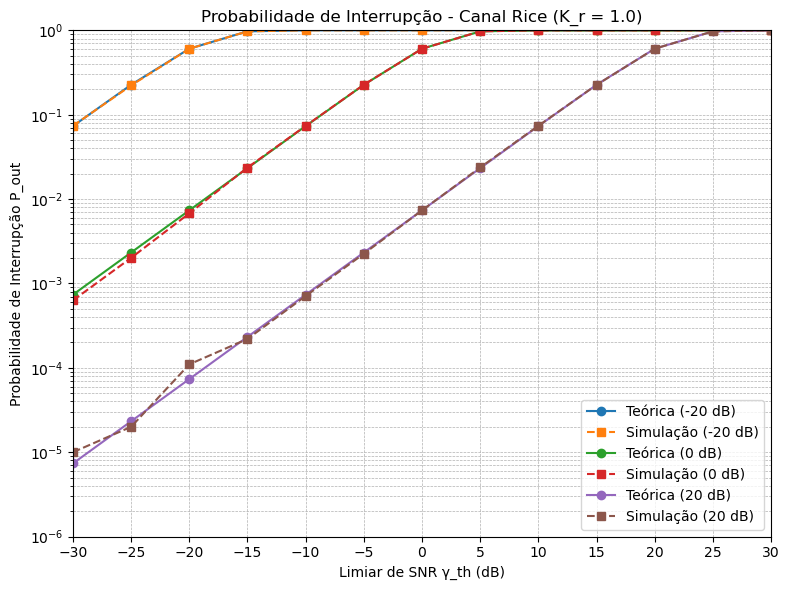

C:\Users\takeshi\AppData\Local\Temp\ipykernel_23476\1034097603.py:131: IntegrationWarning: The occurrence of roundoff error is detected, which prevents 
  the requested tolerance from being achieved.  The error may be 
  underestimated.
  result, error = integrate.quad(integrand, b, 100,


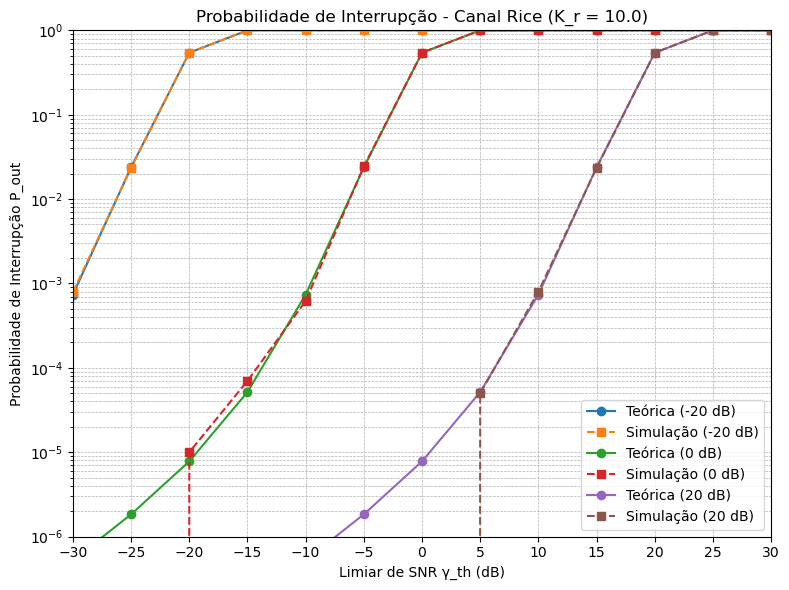

Número de amostras (Nt)
100000
Semente:
2025


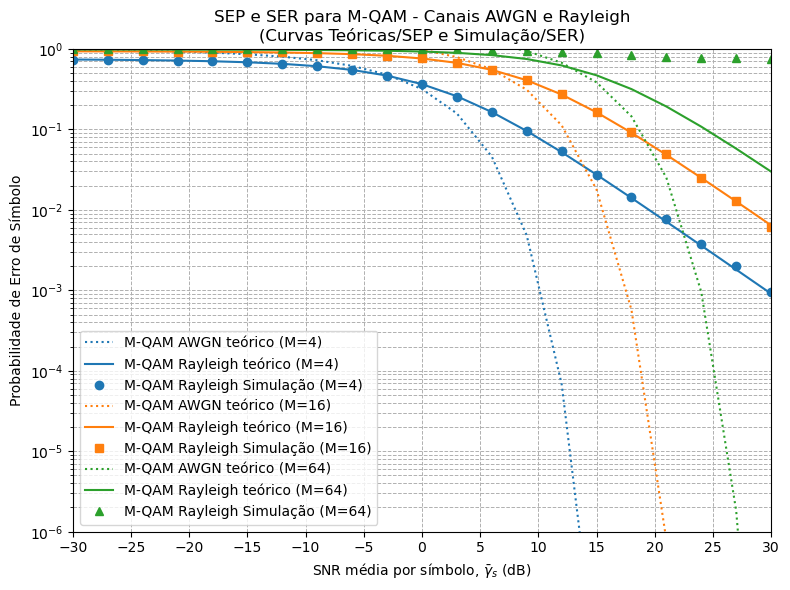

In [7]:
#UNIVERSIDADE DE BRASÍLIA 
#FACULDADE DE TECNOLOGIA
#DEPARTAMENTO DE ENGENHARIA ELÉTRICA
#PROGRAMA DE PÓS-GRADUAÇÃO EM ENGENHARIA ELÉTRICA
#PPGEE3622 – COMUNICAÇÕES MÓVEIS
#TAKESHI IKEDA - 252104269
#ATIVIDADE 002
#DESEMPENHO DOS SISTEMAS DE COMUNICAÇÕES SEM FIO
#DOCENTE: HIGO THAIAN PEREIRA DA SILVA

#1.(a) Simulação da probabilidade de interrupção com envoltória Rayleigh


import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator

# Número de amostras (Nt)
Nt = 10**5

print("Número de amostras (Nt)")
print(Nt)

# Variância
# Pot. ruído para Es = 1 -> sigma² = 1/2 (gamma_s)
#                        variância = 1/2 * SNR_símbolo
sigma = np.sqrt(1/2)

# Limiar de SNR (gamma_th) - eixo x variando de -30 dB a 30 dB 
gamma_th_db = np.arange(-30, 31, 5)
gamma_th_lin = 10**(gamma_th_db / 10)

# SNR média por símbolo (gamma_s_barra)
# valores fixos: −20 dB, 0 dB, 20 dB
gamma_s_barra_db = np.array([-20, 0, 20])
gamma_s_barra_lin = 10**(gamma_s_barra_db / 10)

# Envoltória do canal (Rayleigh normalizado)
x = np.random.normal(0, sigma, Nt)
y = np.random.normal(0, sigma, Nt)
beta = np.sqrt(x**2 + y**2)

plt.figure(figsize=(8, 6))

# Loop sobre cada SNR média ()
for g_med_db, g_med in zip(gamma_s_barra_db, gamma_s_barra_lin):
    # SNR instantânea
    snr_inst = g_med * beta**2

    # Estimativa simulação da probabilidade de Interrupção
    p_out_sim = []
    for g_th in gamma_th_lin:
        interrupcao = snr_inst <= g_th
        p_out_sim.append(np.sum(interrupcao) / Nt)
    p_out_sim = np.array(p_out_sim)

    # Solução Teórica para canal Rayleigh
    p_out_teo = 1 - np.exp(-gamma_th_lin / g_med)

    # Plotar ambas
    plt.semilogy(gamma_th_db, p_out_teo, 'o-', label=f'Teórica ({g_med_db} dB)')
    plt.semilogy(gamma_th_db, p_out_sim, 's--', label=f'Simulação ({g_med_db} dB)')

# Configurações do gráfico
plt.grid(True, which="both", ls="--", lw=0.5)
plt.xlabel('Limiar de SNR γ_th (dB)')
plt.ylabel('Probabilidade de Interrupção P_out')
plt.title('Probabilidade de Interrupção - Canal Rayleigh')
plt.legend()
plt.ylim(1e-6, 1)
plt.xlim(-30, 30)
ax = plt.gca()
ax.xaxis.set_major_locator(MultipleLocator(5))
plt.tight_layout()
plt.show()


#1.(b) Simulação da probabilidade de interrupção com envoltória Rice

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator
#import marcumq as q

#------
from scipy import integrate
from scipy.special import iv, i0

def marcumq(m, a, b, max_limit=50, tol=1e-10):
    """
    Implementação robusta da função Marcum Q
    
    Parameters:
    m : ordem (m >= 1)
    a, b : parâmetros
    max_limit : limite superior da integral
    tol : tolerância
    """
    try:
        # Primeiro tentar a função oficial se disponível
        #scipy_marcumq = q
        from scipy.special import marcumq as q
        return q(m, a, b)
    except ImportError:
        # Implementação manual
        def integrand(x):
            return x * (x/a)**(m-1) * np.exp(-(x**2 + a**2)/2) * iv(m-1, a*x)
        
        try:
            # Tentar integração numérica
            result, error = integrate.quad(integrand, b, max_limit, 
                                         epsabs=tol, epsrel=tol, limit=100)
            return result
        except:
            # Método trapezoidal como fallback
            x_vals = np.linspace(b, max_limit, 50000)
            y_vals = integrand(x_vals)
            return np.trapz(y_vals, x_vals)

def marcum_q1(a, b):
    """Marcum Q de ordem 1 - implementação específica"""
    try:
        from scipy.special import marcumq
        return marcumq(1, a, b)
    except ImportError:
        # Implementação manual para Q1
        def integrand(x):
            return x * np.exp(-(x**2 + a**2)/2) * i0(a*x)
        
        try:
            result, error = integrate.quad(integrand, b, 100, 
                                         epsabs=1e-12, epsrel=1e-12)
            return result
        except:
            # Método trapezoidal
            x = np.linspace(b, 100, 100000)
            y = x * np.exp(-(x**2 + a**2)/2) * i0(a*x)
            return np.trapz(y, x)

#-------

# Número de amostras de SNR (Nt)

Nt = 10**5
print("Número de amostras (Nt)")
print(Nt)


# Variância (Rice normalizado (beta): 2*sigma² = 1)
# valores de kr = 0.1 / 1 / 10
kr_factor = np.array([0.1, 1, 10])

# Limiar de SNR (gamma_th) - eixo x variando de -30 dB a 30 dB 
gamma_th_db = np.arange(-30, 31, 5)
gamma_th_lin = 10**(gamma_th_db / 10)

# SNR média por símbolo (gamma_s_barra)
gamma_s_barra_db = np.array([-20, 0, 20])
gamma_s_barra_lin = 10**(gamma_s_barra_db / 10)

for kr in kr_factor:
    plt.figure(figsize=(8, 6))

    # Cálculo da probabilidade de outage para canal Rice
    for g_med_db, g_med in zip(gamma_s_barra_db, gamma_s_barra_lin):
        # SNR instantânea por símbolo
        los_power = kr / (kr + 1)
        mu = np.sqrt(los_power)  # valor médio da portadora
        sigma = np.sqrt(1/(2*(kr + 1))) 

        # Envoltória do canal (Rice normalizado)
        x = np.random.normal(0, sigma, Nt)
        y = np.random.normal(0, sigma, Nt)

        beta = np.sqrt((x + mu)**2 + y**2)

        snr_inst = g_med * beta**2

        # Estimativa simulação da probabilidade de Interrupção
        p_out_sim = []

        # Velores Analíticos/Teóricos para o canal Rice
        p_out_teo = []
        for g_th in gamma_th_lin:
            interrupcao = snr_inst <= g_th
            p_out_sim.append(np.sum(interrupcao) / Nt)
            # Solução analítica/teórica para canal Rice
            p_out_teo.append(1 - marcum_q1(a=np.sqrt(2*kr), b=np.sqrt((2*(kr+1)*g_th)/g_med)))


        p_out_sim = np.array(p_out_sim)
        p_out_teo = np.array(p_out_teo)

        # Plotar ambas
        plt.semilogy(gamma_th_db, p_out_teo, 'o-', label=f'Teórica ({g_med_db} dB)')
        plt.semilogy(gamma_th_db, p_out_sim, 's--', label=f'Simulação ({g_med_db} dB)')

    # Configurações do gráfico
    plt.grid(True, which="both", ls="--", lw=0.5)
    plt.xlabel('Limiar de SNR γ_th (dB)')
    plt.ylabel('Probabilidade de Interrupção P_out')
    plt.title(f'Probabilidade de Interrupção - Canal Rice (K_r = {kr})')
    plt.legend()
    plt.ylim(1e-6, 1)
    plt.xlim(-30, 30)
    ax = plt.gca()
    ax.xaxis.set_major_locator(MultipleLocator(5))
    plt.tight_layout()
    plt.show()


#2.(a) Simulação da probabilidade de erro de símbolo sob efeito do desvanecimento Rayleigh
# Além do cálculo teórico, plotar a Taxa de Erro de símbolo (SER)
# Adicionalmente a probabilidade de erro de símbolo para o canal AWGN


import numpy as np
from scipy.stats import norm
import matplotlib.pyplot as plt 
from matplotlib.ticker import MultipleLocator

# Número de amostras (Nt)
Nt = 10**5

print("Número de amostras (Nt)")
print(Nt)

# Semente para possibilitar reprodutibilidade
semente = 2025

print("Semente:")
print(semente)



#  SER em canal AWGN para M-QAM (teórico)

# Probabilidade de erro de símbolo (SER) em canal AWGN para modulação M-QAM (equação 27).
# Entradas: M = ordem de moduação / gama_s_barra_dB = SNR média do sistema
# Retorna Probabiidade de erro de símbolo
def ser_mqam_AWGN(M, gama_s_barra_dB):
   
    # SNR média por símbolo (linear)
    gama_s_barra_lin = 10**(gama_s_barra_dB / 10)  
    k = np.sqrt(M)
    # norm.sf(x) = Q(x) = Função Q de Gauss = P(X > x) para variável normal padrão
    Pe = 4 * (1 - 1/k) * norm.sf(np.sqrt(3 * gama_s_barra_lin / (M - 1)))
    return Pe



#  SER em canal Rayleigh para M-QAM (teórico)

# Probabilidade de erro de símbolo (SER) em canal Rayleigh para modulação M-QAM, usando a expressão em função de C_M. (equação 27).
# Entradas: M = ordem de moduação / gama_s_barra_dB = SNR média do sistema
# Retorna Probabiidade de erro de símbolo
def ser_mqam_Rayleigh_teorico(M, gama_s_barra_dB):
    
    gama_s_barra_lin = 10**(gama_s_barra_dB / 10)  # SNR média por símbolo (linear)

    # C_M(γ̄_s)
    C_M = np.sqrt((1.5 * gama_s_barra_lin) / (M - 1 + 1.5 * gama_s_barra_lin))

    # Fator geométrico da constelação M-QAM
    a = (np.sqrt(M) - 1) / np.sqrt(M)

    Pe = 2 * a * (1 - C_M) - (a**2) * (1 - (4/np.pi) * C_M * np.arctan(1/C_M))
    return Pe



# Geração de constelação M-QAM (M = 4, 16, 64, ...) normalizada (energia média de símbolo normalizada para 1)
# Retorna: os pontos da constelação / vetor com níveis reais (e imaginários)
def gerar_constelacao_mqam(M):
    L = int(np.sqrt(M))
    #"M deve ser quadrado perfeito (4, 16, 64, ...)."
    assert L * L == M

    # Níveis em cada eixo: - (L-1), ..., (L-1) com passo 2 (ex: -3, -1, 1, 3)
    niveis = np.arange(-L + 1, L, 2)

    I, Q = np.meshgrid(niveis, niveis)
    const = I + 1j * Q
    const = const.flatten()

    # Energia média da constelação não normalizada: Es = 2/3 * (M - 1)
    Es = 2/3 * (M - 1)

    # Normalizar para Es_médio = 1
    const = const / np.sqrt(Es)
    niveis_norm = niveis / np.sqrt(Es)

    return const, niveis_norm


#  Simulação Monte Carlo em canal Rayleigh para M-QAM

# Gera Nt símbolos, canal Rayleigh e ruído AWGN para cada SNR.
# Retorna um vetor Pe_MC com mesmo tamanho de gama_s_barra_dB.
def simular_ser_mqam_Rayleigh_MC(M, gama_s_barra_dB, Nt, semente):
    
    rng = np.random.default_rng(semente)

    # Constelação e níveis normalizados
    const, niveis_norm = gerar_constelacao_mqam(M)

    # Sorteio de símbolos transmitidos (índices na constelação)
    idx_tx = rng.integers(0, M, size=Nt)
    s = const[idx_tx]  # símbolos transmitidos (energia média 1)

    # Canal Rayleigh: h ~ CN(0,1)
    h_real = rng.normal(0.0, 1/np.sqrt(2), size=Nt)
    h_imag = rng.normal(0.0, 1/np.sqrt(2), size=Nt)
    beta = h_real + 1j * h_imag

    Pe_MC = np.zeros_like(gama_s_barra_dB, dtype=float)

    # Loop sobre os valores de SNR média por símbolo
    for i, g_dB in enumerate(gama_s_barra_dB):
        gama_s_lin = 10**(g_dB / 10)  # SNR média por símbolo (linear)

        # Es = 1 (constelação normalizada), então N0 = Es / γ̄s = 1 / γ̄s
        # Variância de cada componente do ruído: sigma2 = N0 / 2
        if gama_s_lin > 0:
            sigma2 = 1 / (2 * gama_s_lin)
        else:
            sigma2 = 1e3  # ruído muito forte para SNR média bem negativa

        n_real = rng.normal(0.0, np.sqrt(sigma2), size=Nt)
        n_imag = rng.normal(0.0, np.sqrt(sigma2), size=Nt)
        n = n_real + 1j * n_imag

        # Sinal recebido: r = beta * s + n
        r = beta * s + n

        # Equalização com CSI perfeita: r_eq = r / beta
        r_eq = r / beta

        # Detecção por mínimos quadrados: decidir nível mais próximo por eixo
        rI = r_eq.real
        rQ = r_eq.imag

        dist_I = np.abs(rI[:, None] - niveis_norm[None, :])
        dist_Q = np.abs(rQ[:, None] - niveis_norm[None, :])

        idx_I_hat = np.argmin(dist_I, axis=1)
        idx_Q_hat = np.argmin(dist_Q, axis=1)

        s_hat = niveis_norm[idx_I_hat] + 1j * niveis_norm[idx_Q_hat]

        # Contar erros de símbolo
        erros = np.count_nonzero(s_hat != s)
        Pe_MC[i] = erros / Nt

    return Pe_MC



#  Bloco principal: SER M-QAM em Rayleigh (teórico) e AWGN (teórico)

if __name__ == "__main__":

    M_values = [4, 16, 64]                   # ordens de modulação M-QAM
    gama_s_barra_dB = np.linspace(-30, 30, 21)    # SNR média por símbolo em dB
    plt.figure(figsize=(8, 6))
    cores = ["tab:blue", "tab:orange", "tab:green"]
    marcadores = ["o", "s", "^"]

    for idx, M in enumerate(M_values):
        # Curva teórica AWGN
        Pe_AWGN_teo = ser_mqam_AWGN(M, gama_s_barra_dB)

        # Curva teórica Rayleigh
        Pe_Rayleigh_teo = ser_mqam_Rayleigh_teorico(M, gama_s_barra_dB)

        # Simulação Monte Carlo em Rayleigh
        Pe_Rayleigh_sim = simular_ser_mqam_Rayleigh_MC(M, gama_s_barra_dB, Nt, semente+idx)

        # Plot AWGN teórico (linha pontilhada)
        plt.semilogy(gama_s_barra_dB, Pe_AWGN_teo,
                     color=cores[idx],
                     linestyle=":",
                     label=f"M-QAM AWGN teórico (M={M})")

        # Plot Rayleigh teórico (linha contínua)
        plt.semilogy(gama_s_barra_dB, Pe_Rayleigh_teo,
                     color=cores[idx],
                     linestyle="-",
                     label=f"M-QAM Rayleigh teórico (M={M})")

        # Pontos da simulação Rayleigh (marcadores)
        plt.semilogy(gama_s_barra_dB, Pe_Rayleigh_sim,
                     color=cores[idx],
                     linestyle="",
                     marker=marcadores[idx],
                     markersize=6,
                     label=f"M-QAM Rayleigh Simulação (M={M})")

    plt.xlabel('SNR média por símbolo, $\\bar{\\gamma}_s$ (dB)')
    plt.ylabel('Probabilidade de Erro de Símbolo')
    plt.title('SEP e SER para M-QAM - Canais AWGN e Rayleigh\n'
              '(Curvas Teóricas/SEP e Simulação/SER)')
    plt.grid(True, which='both', linestyle='--', linewidth=0.7)
    plt.legend()
    plt.ylim(1e-6, 1)
    plt.xlim(-30, 30)
    ax = plt.gca()
    ax.xaxis.set_major_locator(MultipleLocator(5))
    plt.tight_layout()
    plt.show(block=False)
